In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/housing.csv")

### EDA

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.shape

(20640, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [12]:
df.isnull().sum()

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64

In [14]:
df = df.dropna()

<Axes: xlabel='median_house_value', ylabel='Count'>

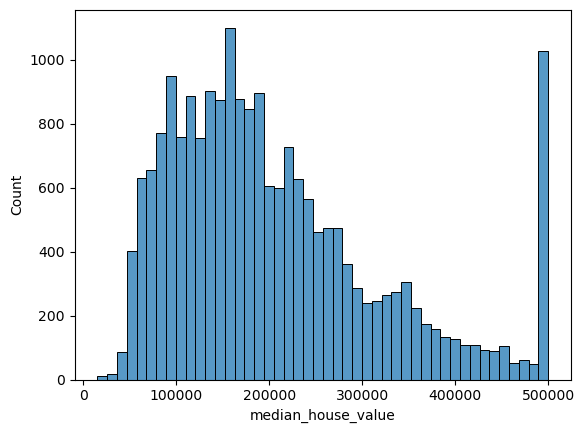

In [16]:
sns.histplot(x = df["median_house_value"])

<Axes: >

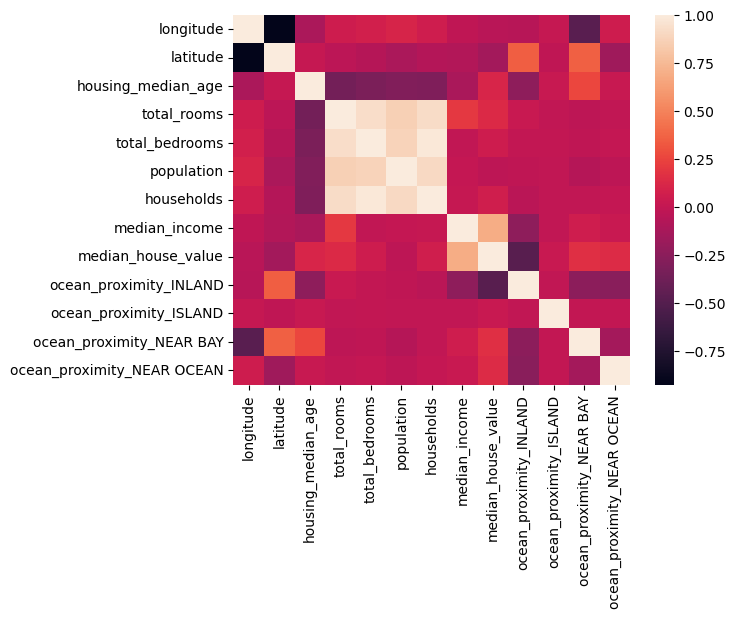

In [17]:
sns.heatmap(df.corr())

<Axes: xlabel='median_house_value', ylabel='median_income'>

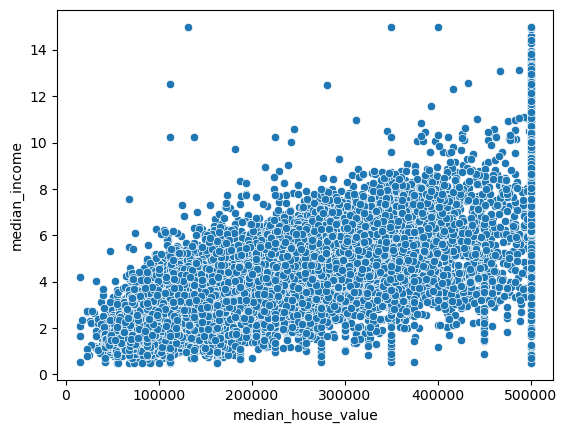

In [18]:
sns.scatterplot(x = df["median_house_value"], y = df["median_income"])

<Axes: xlabel='latitude', ylabel='longitude'>

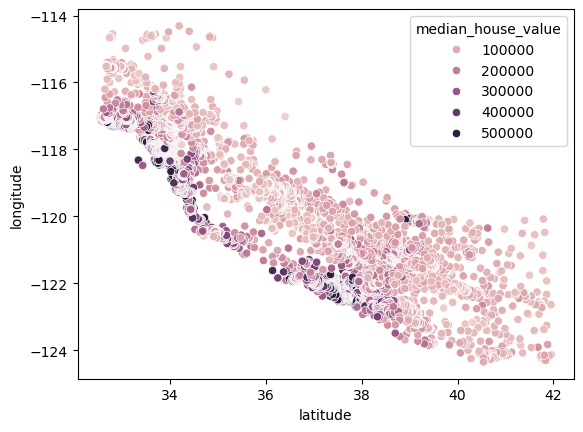

In [20]:
sns.scatterplot(x = df["latitude"], y = df["longitude"], hue = df["median_house_value"])

<Axes: ylabel='total_rooms'>

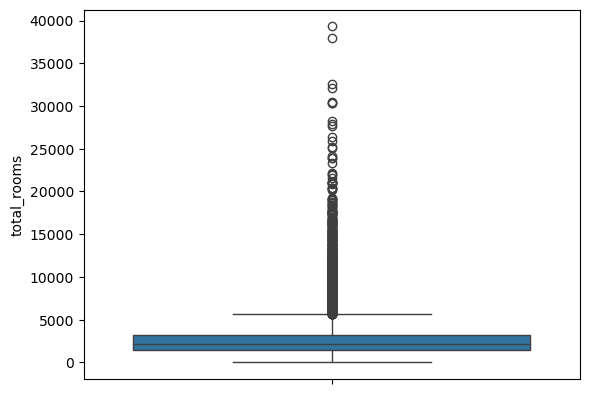

In [22]:
sns.boxplot(y = df["total_rooms"])

<Axes: ylabel='population'>

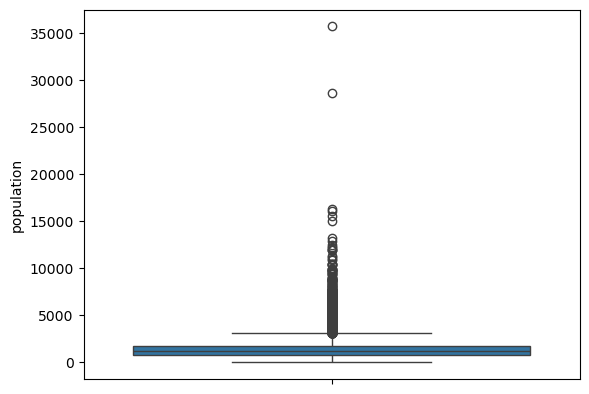

In [23]:
sns.boxplot(y = df["population"])

<Axes: ylabel='households'>

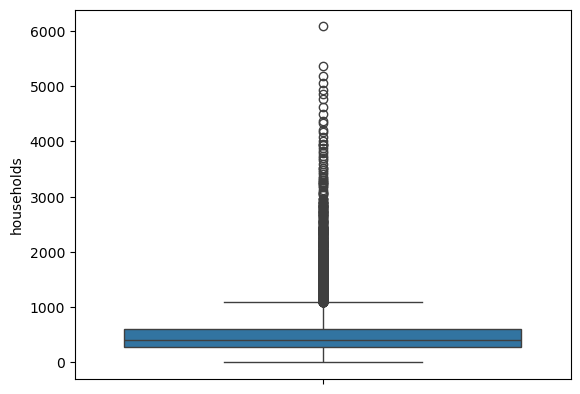

In [24]:
sns.boxplot(y = df["households"])

<Axes: ylabel='total_bedrooms'>

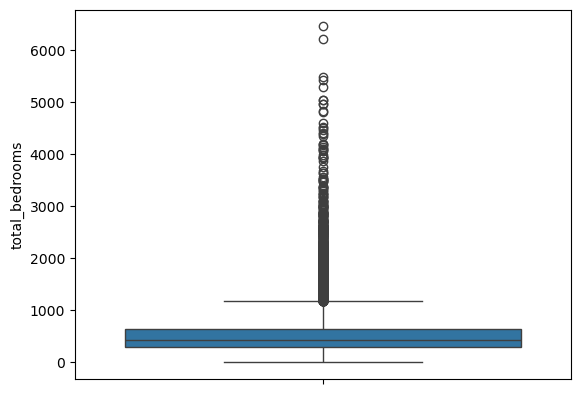

In [25]:
sns.boxplot(y = df["total_bedrooms"])

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [27]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [30]:
X = df.drop(["median_house_value"], axis = 1)
y = df["median_house_value"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y , random_state= 42, test_size= 0.2
)

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LinearRegression, Ridge, LassoCV, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [38]:
linear = LinearRegression()
linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_linear))
print("mse: ", mean_squared_error(y_test, y_pred_linear))
print("score: ", r2_score(y_test, y_pred_linear))
print("rmse: ", root_mean_squared_error(y_test, y_pred_linear))

mae:  50413.43330810037
mse:  4802173538.60416
score:  0.6488402154431994
rmse:  69297.7166911303


In [39]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [41]:
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic= elastic.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_elastic))
print("mse: ", mean_squared_error(y_test, y_pred_elastic))
print("score: ", r2_score(y_test, y_pred_elastic))
print("rmse: ", root_mean_squared_error(y_test, y_pred_elastic))

mae:  57883.995560264644
mse:  5941549012.7741995
score:  0.5655231835153713
rmse:  77081.44402367018


In [42]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge= ridge.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_ridge))
print("mse: ", mean_squared_error(y_test, y_pred_ridge))
print("score: ", r2_score(y_test, y_pred_ridge))
print("rmse: ", root_mean_squared_error(y_test, y_pred_ridge))

mae:  50412.41533637305
mse:  4802177688.914902
score:  0.6488399119509964
rmse:  69297.74663663244


In [43]:
lasso = LassoCV()
lasso.fit(X_train, y_train)
y_pred_lasso= lasso.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_lasso))
print("mse: ", mean_squared_error(y_test, y_pred_lasso))
print("score: ", r2_score(y_test, y_pred_lasso))
print("rmse: ", root_mean_squared_error(y_test, y_pred_lasso))

mae:  50404.70598008599
mse:  4803110145.254339
score:  0.6487717259171862
rmse:  69304.47420805051


In [47]:
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr= svr.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_svr))
print("mse: ", mean_squared_error(y_test, y_pred_svr))
print("score: ", r2_score(y_test, y_pred_svr))
print("rmse: ", root_mean_squared_error(y_test, y_pred_svr))

mae:  89571.17346156703
mse:  14330119903.735182
score:  -0.04789253816334549
rmse:  119708.47882976035


In [63]:
tree = DecisionTreeRegressor(max_depth= 8)
tree.fit(X_train, y_train)
y_pred_tree= tree.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_tree))
print("mse: ", mean_squared_error(y_test, y_pred_tree))
print("score: ", r2_score(y_test, y_pred_tree))
print("rmse: ", root_mean_squared_error(y_test, y_pred_tree))

mae:  43083.12129065485
mse:  4043901831.737219
score:  0.7042889673632122
rmse:  63591.680522983654


In [64]:
tree.score(X_train, y_train)

0.7581278074803461

In [65]:
tree.score(X_test, y_test)

0.7042889673632122

In [ ]:
params = {"max_depth": range(1,20)}

In [82]:
grid = GridSearchCV(param_grid= params, estimator=tree, n_jobs=-1)

In [83]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeR...r(max_depth=8)
,param_grid,"{'max_depth': range(1, 30)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [84]:
y_pred_grid_new = grid.predict(X_test)
print("mae: ", mean_absolute_error(y_test, y_pred_grid_new))
print("mse: ", mean_squared_error(y_test, y_pred_grid_new))
print("score: ", r2_score(y_test, y_pred_grid_new))
print("rmse: ", root_mean_squared_error(y_test, y_pred_grid_new))

mae:  40703.200250815156
mse:  3839405320.4575367
score:  0.7192428107148341
rmse:  61962.93505360714
